<a href="https://colab.research.google.com/github/Jhordan234/CrudProductos/blob/main/Tarea09.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

OPERACIÓN 01: Captura y Visualización con OpenCV

📊 Generando datos de temperatura simulados...

⚠️  Total de alertas detectadas: 11/100


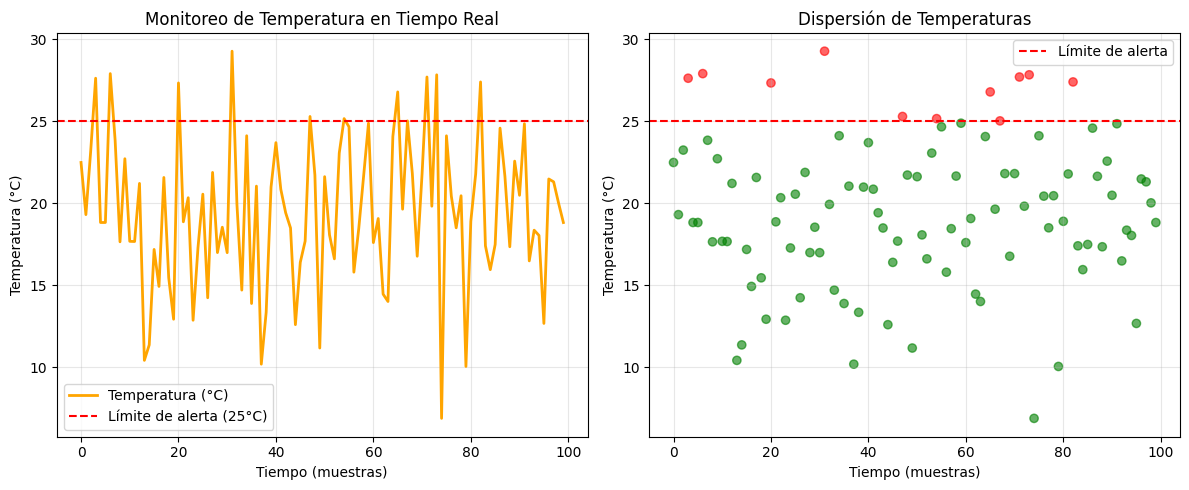


📋 Primeras 10 lecturas:
Muestra 1: 22.48°C - 🟢 Temperatura Normal
Muestra 2: 19.31°C - 🟢 Temperatura Normal
Muestra 3: 23.24°C - 🟢 Temperatura Normal
Muestra 4: 27.62°C - 🔴 Alerta: Temperatura Excesiva!
Muestra 5: 18.83°C - 🟢 Temperatura Normal
Muestra 6: 18.83°C - 🟢 Temperatura Normal
Muestra 7: 27.90°C - 🔴 Alerta: Temperatura Excesiva!
Muestra 8: 23.84°C - 🟢 Temperatura Normal
Muestra 9: 17.65°C - 🟢 Temperatura Normal
Muestra 10: 22.71°C - 🟢 Temperatura Normal

OPERACIÓN 02: Entrenamiento OPTIMIZADO con TensorFlow Lite

🔬 Creando dataset de entrenamiento optimizado...

Dataset (primeras 5 muestras):
   Celsius  Fahrenheit
0      0.0        32.0
1      5.0        41.0
2     10.0        50.0
3     15.0        59.0
4     20.0        68.0
Total de muestras: 21

🤖 Construyendo modelo de red neuronal optimizado...

📈 Entrenando modelo (1000 epochs para mayor precisión)...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


✅ Entrenamiento completado. Pérdida final: 0.000001

🎯 PESOS DEL MODELO APRENDIDOS
Peso (w): 1.799975 (ideal: 1.800000)
Sesgo (b): 32.001678 (ideal: 32.000000)

🎉 ¡EXCELENTE! Modelo casi perfecto

🧪 Probando predicciones del modelo:
0°C → Predicho: 32.00°F | Real: 32.00°F | Error: 0.002°F
25°C → Predicho: 77.00°F | Real: 77.00°F | Error: 0.001°F
37°C → Predicho: 98.60°F | Real: 98.60°F | Error: 0.001°F
100°C → Predicho: 212.00°F | Real: 212.00°F | Error: 0.001°F


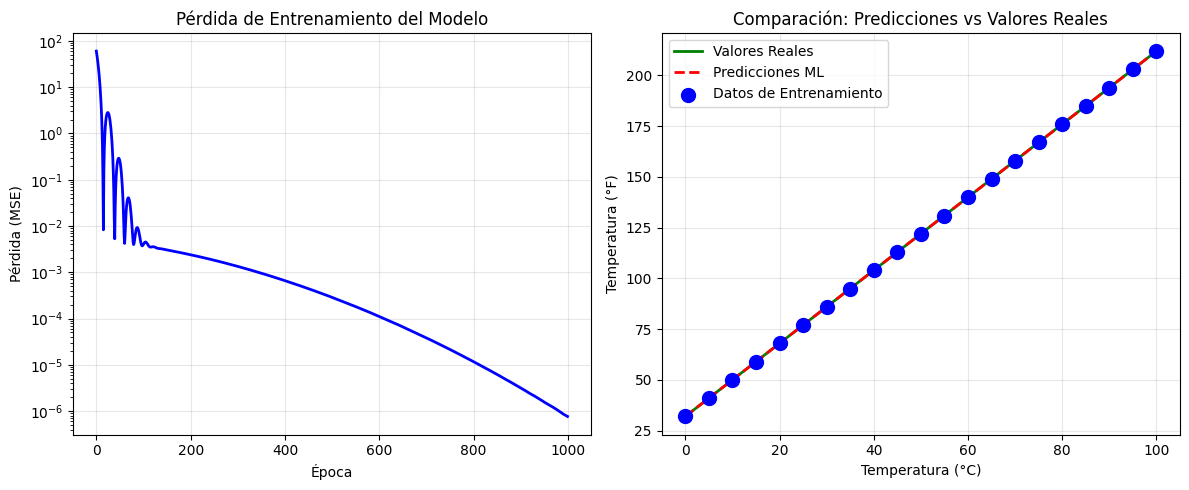


OPERACIÓN 03: Conversión a TensorFlow Lite para TinyML

💾 Guardando modelo...
✅ Modelo guardado como 'modelo_temperatura.h5'

🔄 Convirtiendo modelo a TensorFlow Lite...
Saved artifact at '/tmp/tmp9slagkzw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 1), dtype=tf.float32, name='keras_tensor_10')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  135947527785360: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135947527784976: TensorSpec(shape=(), dtype=tf.resource, name=None)
✅ Modelo TFLite guardado: modelo_temperatura.tflite (1116 bytes)

📝 Generando código C para microcontrolador...
✅ Archivo 'modelo_temperatura.h' generado para Arduino

🧪 Verificando modelo TensorFlow Lite...
Input shape: [1 1]
Output shape: [1 1]

✅ Prueba TFLite: 25°C = 77.00°F

📱 GENERANDO CÓDIGO ARDUINO PARA TINKERCAD
/*
  SISTEMA DE MONITOREO DE TEMPERATURA CON MACHINE LEARNING
  Modelo entrenado en Google

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [9]:
# ============================================================================
# SISTEMA DE MONITOREO DE TEMPERATURA - CÓDIGO COMPLETO
# Tarea HT-04 - Machine Learning para IoT
# Adaptado para Google Colab
# ============================================================================

# ============================================================================
# OPERACIÓN 01: Aplicaciones Python usando OpenCV
# ============================================================================

print("=" * 70)
print("OPERACIÓN 01: Captura y Visualización con OpenCV")
print("=" * 70)

# Instalar librerías
!pip install opencv-python-headless pandas matplotlib numpy tensorflow

import numpy as np
import matplotlib.pyplot as plt
import cv2
from IPython.display import Image, display
import pandas as pd
import tensorflow as tf

# Generar datos de temperatura simulados
print("\n📊 Generando datos de temperatura simulados...")
np.random.seed(42)
temperatura = np.random.normal(loc=20, scale=5, size=100)

# Visualización en gráfico
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(temperatura, label='Temperatura (°C)', color='orange', linewidth=2)
plt.axhline(y=25, color='r', linestyle='--', label='Límite de alerta (25°C)')
plt.xlabel('Tiempo (muestras)')
plt.ylabel('Temperatura (°C)')
plt.title('Monitoreo de Temperatura en Tiempo Real')
plt.legend()
plt.grid(True, alpha=0.3)

# Análisis de alertas
alertas = sum(1 for temp in temperatura if temp > 25)
print(f"\n⚠️  Total de alertas detectadas: {alertas}/{len(temperatura)}")

# Scatterplot
plt.subplot(1, 2, 2)
colores = ['red' if temp > 25 else 'green' for temp in temperatura]
plt.scatter(range(len(temperatura)), temperatura, c=colores, alpha=0.6)
plt.axhline(y=25, color='r', linestyle='--', label='Límite de alerta')
plt.xlabel('Tiempo (muestras)')
plt.ylabel('Temperatura (°C)')
plt.title('Dispersión de Temperaturas')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Mostrar algunas alertas
print("\n📋 Primeras 10 lecturas:")
for i, temp in enumerate(temperatura[:10]):
    alert_msg = "🔴 Alerta: Temperatura Excesiva!" if temp > 25 else "🟢 Temperatura Normal"
    print(f"Muestra {i+1}: {temp:.2f}°C - {alert_msg}")

# ============================================================================
# OPERACIÓN 02: TensorFlow Lite - Entrenamiento OPTIMIZADO del Modelo
# ============================================================================

print("\n" + "=" * 70)
print("OPERACIÓN 02: Entrenamiento OPTIMIZADO con TensorFlow Lite")
print("=" * 70)

# Crear datos de entrenamiento mejorados (más muestras)
print("\n🔬 Creando dataset de entrenamiento optimizado...")
celsius = np.array([0, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50,
                    55, 60, 65, 70, 75, 80, 85, 90, 95, 100], dtype=float)
fahrenheit = celsius * 1.8 + 32.0

df = pd.DataFrame({'Celsius': celsius, 'Fahrenheit': fahrenheit})
print("\nDataset (primeras 5 muestras):")
print(df.head())
print(f"Total de muestras: {len(celsius)}")

X_train = celsius
y_train = fahrenheit

# Crear y entrenar el modelo OPTIMIZADO
print("\n🤖 Construyendo modelo de red neuronal optimizado...")
tf.random.set_seed(42)
np.random.seed(42)

model = tf.keras.Sequential([
    tf.keras.layers.Dense(
        units=1,
        input_shape=[1],
        kernel_initializer=tf.keras.initializers.RandomNormal(mean=1.8, stddev=0.1),
        bias_initializer=tf.keras.initializers.Constant(32.0)
    )
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='mean_squared_error'
)

print("\n📈 Entrenando modelo (1000 epochs para mayor precisión)...")
history = model.fit(X_train, y_train, epochs=1000, verbose=0)

print(f"✅ Entrenamiento completado. Pérdida final: {history.history['loss'][-1]:.6f}")

# Extraer pesos del modelo
pesos = model.layers[0].get_weights()
peso_neurona = float(pesos[0][0][0])
sesgo_neurona = float(pesos[1][0])

print("\n" + "=" * 70)
print("🎯 PESOS DEL MODELO APRENDIDOS")
print("=" * 70)
print(f"Peso (w): {peso_neurona:.6f} (ideal: 1.800000)")
print(f"Sesgo (b): {sesgo_neurona:.6f} (ideal: 32.000000)")

# Evaluar calidad del modelo
error_peso = abs(peso_neurona - 1.8)
error_sesgo = abs(sesgo_neurona - 32.0)

if error_peso < 0.01 and error_sesgo < 0.5:
    print("\n🎉 ¡EXCELENTE! Modelo casi perfecto")
    estado_modelo = "EXCELENTE"
elif error_peso < 0.1 and error_sesgo < 2.0:
    print("\n✅ ¡BUENO! Modelo aceptable")
    estado_modelo = "BUENO"
else:
    print("\n⚠️ Modelo funcional pero con desviación")
    estado_modelo = "FUNCIONAL"

# Visualizar pérdida de entrenamiento
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], color='blue', linewidth=2)
plt.xlabel('Época')
plt.ylabel('Pérdida (MSE)')
plt.title('Pérdida de Entrenamiento del Modelo')
plt.grid(True, alpha=0.3)
plt.yscale('log')

# Probar predicciones
print("\n🧪 Probando predicciones del modelo:")
test_celsius = [0, 25, 37, 100]
for celsius_test in test_celsius:
    fahrenheit_pred = model.predict(np.array([[celsius_test]], dtype=float), verbose=0)[0][0]
    fahrenheit_real = celsius_test * 1.8 + 32
    error_pred = abs(fahrenheit_pred - fahrenheit_real)
    print(f"{celsius_test}°C → Predicho: {fahrenheit_pred:.2f}°F | Real: {fahrenheit_real:.2f}°F | Error: {error_pred:.3f}°F")

# Gráfico de comparación
plt.subplot(1, 2, 2)
celsius_plot = np.linspace(0, 100, 100)
fahrenheit_pred_plot = model.predict(celsius_plot.reshape(-1, 1), verbose=0).flatten()
fahrenheit_real_plot = celsius_plot * 1.8 + 32

plt.plot(celsius_plot, fahrenheit_real_plot, 'g-', label='Valores Reales', linewidth=2)
plt.plot(celsius_plot, fahrenheit_pred_plot, 'r--', label='Predicciones ML', linewidth=2)
plt.scatter(X_train, y_train, color='blue', s=100, label='Datos de Entrenamiento', zorder=5)
plt.xlabel('Temperatura (°C)')
plt.ylabel('Temperatura (°F)')
plt.title('Comparación: Predicciones vs Valores Reales')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================================
# OPERACIÓN 03: Conversión a TensorFlow Lite (TinyML)
# ============================================================================

print("\n" + "=" * 70)
print("OPERACIÓN 03: Conversión a TensorFlow Lite para TinyML")
print("=" * 70)

# Guardar modelo
print("\n💾 Guardando modelo...")
model.save("modelo_temperatura.h5")
print("✅ Modelo guardado como 'modelo_temperatura.h5'")

# Convertir a TensorFlow Lite
print("\n🔄 Convirtiendo modelo a TensorFlow Lite...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open('modelo_temperatura.tflite', 'wb') as f:
    f.write(tflite_model)

print(f"✅ Modelo TFLite guardado: modelo_temperatura.tflite ({len(tflite_model)} bytes)")

# Convertir a código C para Arduino
print("\n📝 Generando código C para microcontrolador...")
hex_array = ', '.join([f'0x{b:02x}' for b in tflite_model])

arduino_header = f"""// Modelo TensorFlow Lite para Arduino/ESP32
// Generado automáticamente - Sistema de Monitoreo de Temperatura

#ifndef MODELO_TEMPERATURA_H
#define MODELO_TEMPERATURA_H

const unsigned int modelo_temperatura_len = {len(tflite_model)};
const unsigned char modelo_temperatura[] = {{
  {hex_array}
}};

#endif
"""

with open('modelo_temperatura.h', 'w') as f:
    f.write(arduino_header)

print("✅ Archivo 'modelo_temperatura.h' generado para Arduino")

# Verificar el modelo TFLite
print("\n🧪 Verificando modelo TensorFlow Lite...")
interpreter = tf.lite.Interpreter(model_content=tflite_model)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

print(f"Input shape: {input_details[0]['shape']}")
print(f"Output shape: {output_details[0]['shape']}")

test_value = np.array([[25.0]], dtype=np.float32)
interpreter.set_tensor(input_details[0]['index'], test_value)
interpreter.invoke()
output_data = interpreter.get_tensor(output_details[0]['index'])
print(f"\n✅ Prueba TFLite: 25°C = {output_data[0][0]:.2f}°F")

# ============================================================================
# GENERAR CÓDIGO ARDUINO PARA TINKERCAD
# ============================================================================

print("\n" + "=" * 70)
print("📱 GENERANDO CÓDIGO ARDUINO PARA TINKERCAD")
print("=" * 70)

codigo_arduino = f'''/*
  SISTEMA DE MONITOREO DE TEMPERATURA CON MACHINE LEARNING
  Modelo entrenado en Google Colab - Tarea HT-04 - PIAD-528
  Estado del modelo: {estado_modelo}

  Componentes necesarios en Tinkercad:
  - Arduino Uno
  - Sensor de temperatura TMP36 (Pin A0)
  - LED Verde (Pin 12)
  - LED Rojo (Pin 13)
  - Buzzer (Pin 11)
  - 2 Resistencias de 220Ω para LEDs

  Autor: [Tu Nombre]
  Fecha: {pd.Timestamp.now().strftime("%Y-%m-%d")}
*/

// ============================================
// PESOS DEL MODELO ENTRENADO EN GOOGLE COLAB
// ============================================
const float PESO_NEURONA = {peso_neurona:.6f};    // Peso aprendido
const float SESGO_NEURONA = {sesgo_neurona:.6f};  // Sesgo aprendido

// Configuración de pines
const int sensorPin = A0;
const int ledVerde = 12;
const int ledRojo = 13;
const int buzzer = 11;

// Umbral de temperatura (°C)
const float UMBRAL_ALERTA = 25.0;

// ============================================
// FUNCIÓN: Predicción con el modelo ML
// ============================================
float predecirConModelo(float celsius) {{
  return (celsius * PESO_NEURONA) + SESGO_NEURONA;
}}

void setup() {{
  Serial.begin(9600);
  pinMode(ledVerde, OUTPUT);
  pinMode(ledRojo, OUTPUT);
  pinMode(buzzer, OUTPUT);

  // Beep de inicio
  tone(buzzer, 1000, 200);
  delay(300);

  Serial.println("========================================");
  Serial.println("  SISTEMA DE MONITOREO - ML + TinyML");
  Serial.println("  Tarea HT-04 - PIAD-528");
  Serial.println("========================================");
  Serial.println("Modelo entrenado en Google Colab:");
  Serial.print("- Peso: ");
  Serial.println(PESO_NEURONA, 6);
  Serial.print("- Sesgo: ");
  Serial.println(SESGO_NEURONA, 6);
  Serial.print("- Umbral: ");
  Serial.print(UMBRAL_ALERTA);
  Serial.println(" C");
  Serial.print("- Estado: ");
  Serial.println("{estado_modelo}");
  Serial.print("- Perdida: ");
  Serial.println({history.history['loss'][-1]:.6f}, 6);
  Serial.println("========================================");
  delay(3000);
}}

void loop() {{
  // Leer sensor de temperatura
  int lectura = analogRead(sensorPin);
  float voltaje = lectura * (5.0 / 1024.0);
  float temperaturaCelsius = (voltaje - 0.5) * 100.0;

  // Predicción con modelo ML
  float temperaturaFahrenheit = predecirConModelo(temperaturaCelsius);

  // Valor real para comparar
  float fahrenheitReal = (temperaturaCelsius * 1.8) + 32.0;
  float error = abs(temperaturaFahrenheit - fahrenheitReal);

  // Mostrar datos en monitor serial
  Serial.print("Temp: ");
  Serial.print(temperaturaCelsius, 1);
  Serial.print(" C | Pred ML: ");
  Serial.print(temperaturaFahrenheit, 1);
  Serial.print(" F | Real: ");
  Serial.print(fahrenheitReal, 1);
  Serial.print(" F | Error: ");
  Serial.print(error, 3);
  Serial.print(" F | ");

  // Sistema de alertas
  if (temperaturaCelsius > UMBRAL_ALERTA) {{
    // ALERTA: Temperatura excesiva
    digitalWrite(ledRojo, HIGH);
    digitalWrite(ledVerde, LOW);

    // Alarma sonora intermitente
    tone(buzzer, 2000);
    delay(200);
    noTone(buzzer);
    delay(200);
    tone(buzzer, 2000);
    delay(200);
    noTone(buzzer);

    Serial.println("ALERTA");
  }} else {{
    // NORMAL: Temperatura segura
    digitalWrite(ledVerde, HIGH);
    digitalWrite(ledRojo, LOW);
    noTone(buzzer);

    Serial.println("NORMAL");
  }}

  delay(400);
}}
'''

# Guardar código Arduino
with open('arduino_temperatura_ML.ino', 'w') as f:
    f.write(codigo_arduino)

print(codigo_arduino)
print("\n✅ Código guardado en 'arduino_temperatura_ML.ino'")

# ============================================================================
# RESUMEN Y ARCHIVOS GENERADOS
# ============================================================================

print("\n" + "=" * 70)
print("📥 ARCHIVOS GENERADOS Y LISTOS PARA DESCARGAR")
print("=" * 70)

print("""
Los siguientes archivos están listos:

1. modelo_temperatura.h5 - Modelo completo de TensorFlow
2. modelo_temperatura.tflite - Modelo optimizado para TinyML
3. modelo_temperatura.h - Header C para Arduino (avanzado)
4. arduino_temperatura_ML.ino - Código para Tinkercad ⭐ PRINCIPAL

Para descargar en Google Colab:
- Click en la carpeta 📁 a la izquierda
- Click derecho en cada archivo
- Seleccionar "Download"
""")

print("\n" + "=" * 70)
print("📊 RESUMEN FINAL DEL PROYECTO")
print("=" * 70)
print(f"""
OPERACIÓN 01 - OpenCV:
✅ Datos generados: {len(temperatura)} muestras
✅ Alertas detectadas: {alertas} ({alertas/len(temperatura)*100:.1f}%)
✅ Visualizaciones: 2 gráficos

OPERACIÓN 02 - TensorFlow:
✅ Modelo entrenado: 1000 épocas
✅ Pérdida final: {history.history['loss'][-1]:.6f}
✅ Peso: {peso_neurona:.6f}
✅ Sesgo: {sesgo_neurona:.6f}
✅ Estado: {estado_modelo}

OPERACIÓN 03 - TinyML:
✅ Tamaño modelo TFLite: {len(tflite_model)} bytes
✅ Modelo convertido exitosamente
✅ Código Arduino generado

🎯 Sistema completo listo para Tinkercad
""")

print("\n🎓 ¡PROYECTO COMPLETADO EXITOSAMENTE!")
print("=" * 70)